# HW10-11:
# Тема: компьютерное зрение в PyTorch.
# Часть S10: CNN, аугментации, transfer learning на ResNet.
# Часть S11: детекция или сегментация, корректная визуализация и базовая валидация.

# Импорты и настройка окружения


In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks

# Фиксация seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Определение устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Создание папок для артефактов
os.makedirs('artifacts/figures', exist_ok=True)

Device: cpu


#  Загрузка датасета для классификации (Часть A)

Train size: 4000
Val size: 1000
Test size: 8000


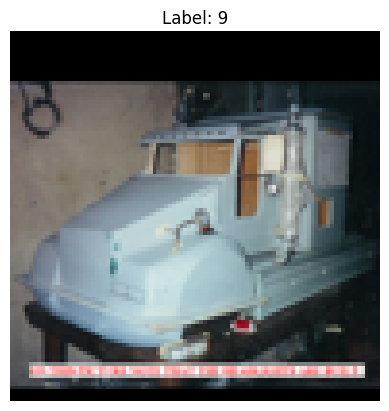

In [2]:
DATASET_NAME = 'STL10'  

if DATASET_NAME == 'STL10':
    train_dataset_full = torchvision.datasets.STL10(
        root='./data', split='train', download=True
    )
    test_dataset = torchvision.datasets.STL10(
        root='./data', split='test', download=True
    )
    
    # Разделение train на train/val (80/20)
    indices = list(range(len(train_dataset_full)))
    random.shuffle(indices)
    split = int(0.8 * len(indices))
    train_indices = indices[:split]
    val_indices = indices[split:]
    
    train_dataset = Subset(train_dataset_full, train_indices)
    val_dataset = Subset(train_dataset_full, val_indices)
    
    num_classes = 10
    img_size = 96

elif DATASET_NAME == 'CIFAR100':
    train_dataset = torchvision.datasets.CIFAR100(
        root='./data', train=True, download=True
    )
    test_dataset = torchvision.datasets.CIFAR100(
        root='./data', train=False, download=True
    )
    val_dataset, _ = torch.utils.data.random_split(train_dataset, [45000, 5000])
    num_classes = 100
    img_size = 32

# Sanity check
print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

# Пример изображения
img, label = train_dataset[0]
if isinstance(img, np.ndarray):
    img = Image.fromarray(img)
plt.imshow(img)
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

# Transforms для классификации

In [3]:
# Базовый transform (без аугментаций) для C1
base_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Transform с аугментациями для C2
aug_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Transform для ResNet (pretrained)
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Применение transforms к датасетам
train_dataset_base = train_dataset  # Для C1
train_dataset_aug = train_dataset   # Для C2
train_dataset_resnet = train_dataset  # Для C3 и C4

# DataLoader для классификации

Для C1 (без аугментаций)

In [4]:
BATCH_SIZE = 64
NUM_WORKERS = 0

from torch.utils.data import Dataset

class TransformDataset(Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset_c1 = TransformDataset(train_dataset, base_transform)
val_dataset_c1 = TransformDataset(val_dataset, base_transform)
test_dataset_c1 = TransformDataset(test_dataset, base_transform)

train_loader_c1 = DataLoader(
    train_dataset_c1, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=False
)
val_loader_c1 = DataLoader(
    val_dataset_c1, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=False
)
test_loader_c1 = DataLoader(
    test_dataset_c1, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=False
)

Для C2 (с аугментациями)

In [5]:
train_dataset_c2 = TransformDataset(train_dataset, aug_transform)
val_dataset_c2 = TransformDataset(val_dataset, base_transform)

train_loader_c2 = DataLoader(
    train_dataset_c2, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=False
)
val_loader_c2 = DataLoader(
    val_dataset_c2, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=False
)

Для C3 и C4 (ResNet)

In [6]:
train_dataset_resnet = TransformDataset(train_dataset, resnet_transform)
val_dataset_resnet = TransformDataset(val_dataset, resnet_transform)
test_dataset_resnet = TransformDataset(test_dataset, resnet_transform)

train_loader_resnet = DataLoader(
    train_dataset_resnet, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=False
)
val_loader_resnet = DataLoader(
    val_dataset_resnet, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=False
)
test_loader_resnet = DataLoader(
    test_dataset_resnet, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=False
)

Проверка что всё работает

In [7]:
images, labels = next(iter(train_loader_c1))
print(f"images.shape: {images.shape}")
print(f"labels.shape: {labels.shape}")
print(f"images type: {type(images)}")

images.shape: torch.Size([64, 3, 96, 96])
labels.shape: torch.Size([64])
images type: <class 'torch.Tensor'>


# Простая CNN архитектура (для C1 и C2)

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten()
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Инициализация модели
model_cnn = SimpleCNN(num_classes=num_classes).to(device)
print(model_cnn)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Flatten(start_dim=1, end_dim=-1)
  )
  (classifier): Sequential(
    (0): Linear(in_features=18432, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


# Функции обучения и оценки (Часть A)

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

# Эксперимент C1 (Simple CNN без аугментаций)

In [10]:
print("=" * 50)
print("Эксперимент C1: Simple CNN без аугментаций")
print("=" * 50)

model_c1 = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_c1.parameters(), lr=0.001)

EPOCHS = 20
history_c1 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model_c1, train_loader_c1, criterion, optimizer, device
    )
    val_loss, val_acc = evaluate(model_c1, val_loader_c1, criterion, device)
    
    history_c1['train_loss'].append(train_loss)
    history_c1['val_loss'].append(val_loss)
    history_c1['train_acc'].append(train_acc)
    history_c1['val_acc'].append(val_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f}, Val Acc: {val_acc:.2f}%")

best_val_acc_c1 = max(history_c1['val_acc'])
print(f"Best Val Accuracy C1: {best_val_acc_c1:.2f}%")

Эксперимент C1: Simple CNN без аугментаций
Epoch 5/20 - Train Loss: 1.1235, Val Acc: 53.30%
Epoch 10/20 - Train Loss: 0.4931, Val Acc: 58.40%
Epoch 15/20 - Train Loss: 0.1927, Val Acc: 59.20%
Epoch 20/20 - Train Loss: 0.1106, Val Acc: 59.70%
Best Val Accuracy C1: 60.40%


# Эксперимент C2 (Simple CNN с аугментациями)

In [11]:
print("=" * 50)
print("Эксперимент C2: Simple CNN с аугментациями")
print("=" * 50)

model_c2 = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_c2.parameters(), lr=0.001)

history_c2 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model_c2, train_loader_c2, criterion, optimizer, device 
    )
    val_loss, val_acc = evaluate(model_c2, val_loader_c2, criterion, device)
    
    history_c2['train_loss'].append(train_loss)
    history_c2['val_loss'].append(val_loss)
    history_c2['train_acc'].append(train_acc)
    history_c2['val_acc'].append(val_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f}, Val Acc: {val_acc:.2f}%")

best_val_acc_c2 = max(history_c2['val_acc'])
print(f"Best Val Accuracy C2: {best_val_acc_c2:.2f}%")

Эксперимент C2: Simple CNN с аугментациями
Epoch 5/20 - Train Loss: 1.3049, Val Acc: 55.70%
Epoch 10/20 - Train Loss: 0.9878, Val Acc: 58.90%
Epoch 15/20 - Train Loss: 0.7595, Val Acc: 66.30%
Epoch 20/20 - Train Loss: 0.6150, Val Acc: 65.80%
Best Val Accuracy C2: 66.30%


# Эксперимент C3 (ResNet18 head-only)

In [12]:
print("=" * 50)
print("Эксперимент C3: ResNet18 Head-Only")
print("=" * 50)

# Загрузка pretrained ResNet18
weights = ResNet18_Weights.DEFAULT
model_c3 = resnet18(weights=weights)

# Замораживание backbone
for param in model_c3.parameters():
    param.requires_grad = False

# Замена классификационной головы
num_ftrs = model_c3.fc.in_features
model_c3.fc = nn.Linear(num_ftrs, num_classes)
model_c3 = model_c3.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_c3.fc.parameters(), lr=0.001)

history_c3 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model_c3, train_loader_resnet, criterion, optimizer, device
    )
    val_loss, val_acc = evaluate(model_c3, val_loader_resnet, criterion, device)
    
    history_c3['train_loss'].append(train_loss)
    history_c3['val_loss'].append(val_loss)
    history_c3['train_acc'].append(train_acc)
    history_c3['val_acc'].append(val_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f}, Val Acc: {val_acc:.2f}%")

best_val_acc_c3 = max(history_c3['val_acc'])
print(f"Best Val Accuracy C3: {best_val_acc_c3:.2f}%")

Эксперимент C3: ResNet18 Head-Only
Epoch 5/20 - Train Loss: 0.1883, Val Acc: 92.90%
Epoch 10/20 - Train Loss: 0.1195, Val Acc: 93.90%
Epoch 15/20 - Train Loss: 0.0907, Val Acc: 93.90%
Epoch 20/20 - Train Loss: 0.0767, Val Acc: 93.80%
Best Val Accuracy C3: 94.70%


# Эксперимент C4 (ResNet18 fine-tune)

In [13]:
print("=" * 50)
print("Эксперимент C4: ResNet18 Fine-Tune")
print("=" * 50)

model_c4 = resnet18(weights=weights)

# Размораживание layer4 и fc
for param in model_c4.parameters():
    param.requires_grad = False
for param in model_c4.layer4.parameters():
    param.requires_grad = True

num_ftrs = model_c4.fc.in_features
model_c4.fc = nn.Linear(num_ftrs, num_classes)
model_c4 = model_c4.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([
    {'params': model_c4.layer4.parameters(), 'lr': 0.0001},
    {'params': model_c4.fc.parameters(), 'lr': 0.001}
])

history_c4 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model_c4, train_loader_resnet, criterion, optimizer, device
    )
    val_loss, val_acc = evaluate(model_c4, val_loader_resnet, criterion, device)
    
    history_c4['train_loss'].append(train_loss)
    history_c4['val_loss'].append(val_loss)
    history_c4['train_acc'].append(train_acc)
    history_c4['val_acc'].append(val_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f}, Val Acc: {val_acc:.2f}%")

best_val_acc_c4 = max(history_c4['val_acc'])
print(f"Best Val Accuracy C4: {best_val_acc_c4:.2f}%")

Эксперимент C4: ResNet18 Fine-Tune
Epoch 5/20 - Train Loss: 0.0049, Val Acc: 95.40%
Epoch 10/20 - Train Loss: 0.0011, Val Acc: 96.00%
Epoch 15/20 - Train Loss: 0.0006, Val Acc: 96.00%
Epoch 20/20 - Train Loss: 0.0003, Val Acc: 95.80%
Best Val Accuracy C4: 96.10%


# Выбор лучшей модели и оценка на test

In [14]:
results = {
    'C1': best_val_acc_c1,
    'C2': best_val_acc_c2,
    'C3': best_val_acc_c3,
    'C4': best_val_acc_c4
}

best_exp = max(results, key=results.get)
print(f"Лучший эксперимент: {best_exp} с Val Accuracy: {results[best_exp]:.2f}%")

if best_exp == 'C1':
    best_model = model_c1
    test_loader = test_loader_c1
elif best_exp == 'C2':
    best_model = model_c2
    test_loader = test_loader_c1
elif best_exp == 'C3':
    best_model = model_c3
    test_loader = test_loader_resnet
else:
    best_model = model_c4
    test_loader = test_loader_resnet

# Оценка на test
_, test_accuracy = evaluate(best_model, test_loader, criterion, device)
print(f"Test Accuracy лучшей модели: {test_accuracy:.2f}%")

torch.save(best_model.state_dict(), 'artifacts/best_classifier.pt')

# Сохранение конфига
config = {
    'dataset': DATASET_NAME,
    'experiment': best_exp,
    'num_classes': num_classes,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'seed': SEED,
    'test_accuracy': test_accuracy
}
with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(config, f, indent=4)

Лучший эксперимент: C4 с Val Accuracy: 96.10%
Test Accuracy лучшей модели: 95.42%


# Визуализация результатов классификации

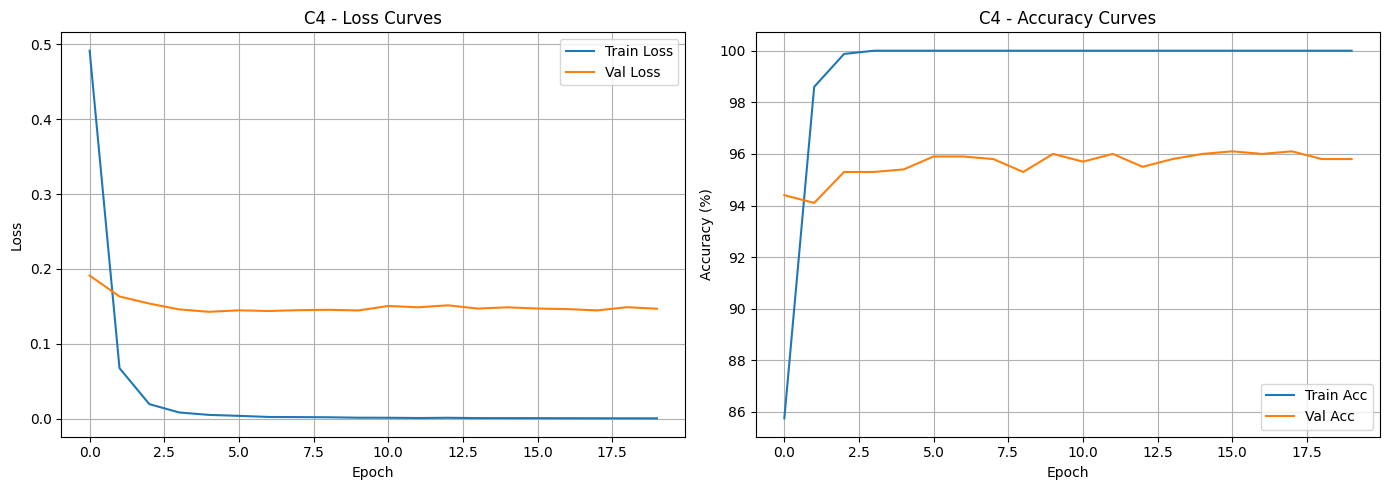

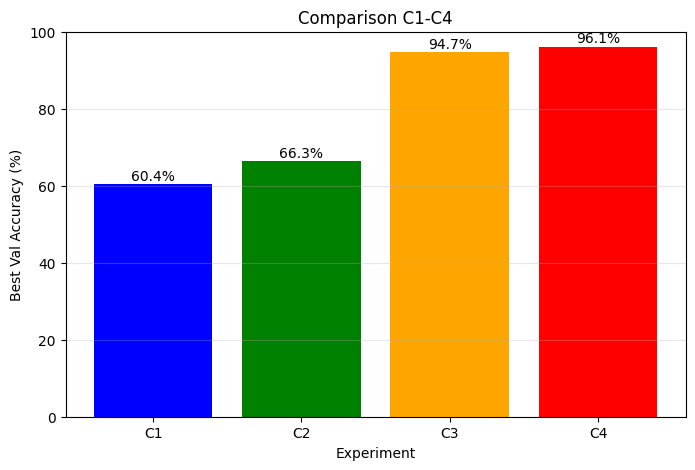

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График обучения лучшей модели
if best_exp == 'C1':
    hist = history_c1
elif best_exp == 'C2':
    hist = history_c2
elif best_exp == 'C3':
    hist = history_c3
else:
    hist = history_c4

axes[0].plot(hist['train_loss'], label='Train Loss')
axes[0].plot(hist['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title(f'{best_exp} - Loss Curves')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(hist['train_acc'], label='Train Acc')
axes[1].plot(hist['val_acc'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title(f'{best_exp} - Accuracy Curves')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/classification_curves_best.png', dpi=150)
plt.show()

# Сравнение начиная с C1 заканчивая C4
experiments = ['C1', 'C2', 'C3', 'C4']
val_accs = [best_val_acc_c1, best_val_acc_c2, best_val_acc_c3, best_val_acc_c4]

plt.figure(figsize=(8, 5))
plt.bar(experiments, val_accs, color=['blue', 'green', 'orange', 'red'])
plt.xlabel('Experiment')
plt.ylabel('Best Val Accuracy (%)')
plt.title('Comparison C1-C4')
plt.ylim(0, 100)
for i, v in enumerate(val_accs):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.grid(axis='y', alpha=0.3)
plt.savefig('artifacts/figures/classification_compare.png', dpi=150)
plt.show()

# Визуализация аугментаций

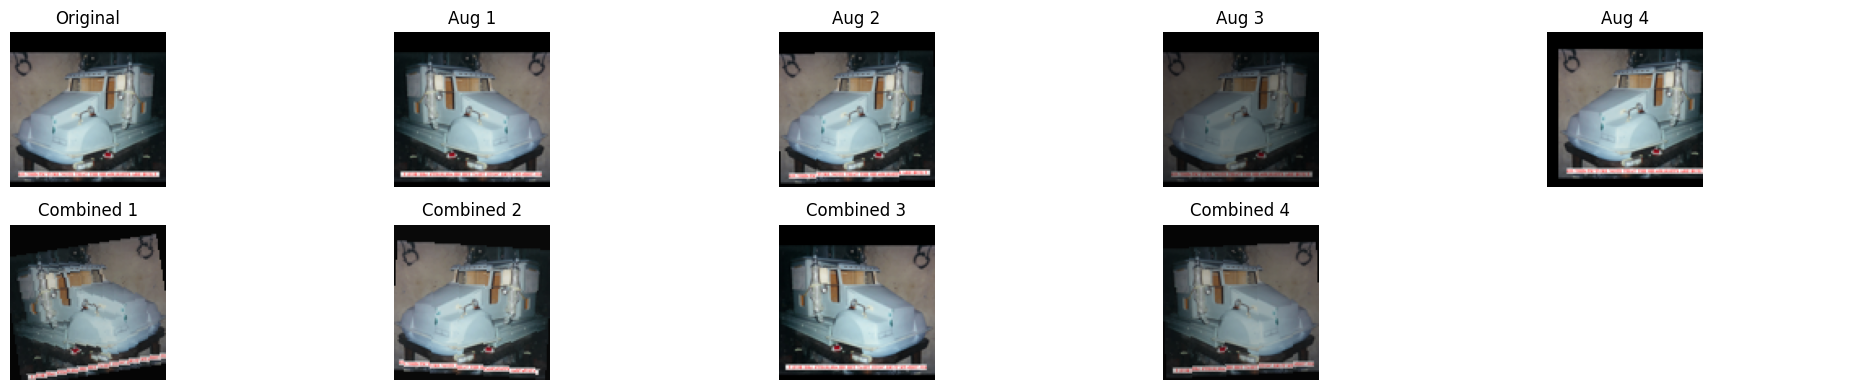

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(20, 4))

# Оригинальное изображение
img, _ = train_dataset[0]
if isinstance(img, np.ndarray):
    img = Image.fromarray(img)

axes[0, 0].imshow(img)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

# Примененные аугментации
for i, transform in enumerate([
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1))
]):
    aug_img = transform(img)
    axes[0, i+1].imshow(aug_img)
    axes[0, i+1].set_title(f'Aug {i+1}')
    axes[0, i+1].axis('off')

# Комбинированные аугментации
combined = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2)
])

for i in range(4):
    aug_img = combined(img)
    axes[1, i].imshow(aug_img)
    axes[1, i].set_title(f'Combined {i+1}')
    axes[1, i].axis('off')

axes[1, 4].axis('off')

plt.tight_layout()
plt.savefig('artifacts/figures/augmentations_preview.png', dpi=150)
plt.show()

# Часть B - Детекция (V1 и V2)

In [17]:
# Загрузка pretrained детектора
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model_det = fasterrcnn_resnet50_fpn(weights=weights)
model_det = model_det.to(device)
model_det.eval()

# Загрузка примеров для детекции
det_dataset = torchvision.datasets.VOCDetection(
    root='./data', year='2012', image_set='val', download=True
)

def run_detection(model, img_tensor, score_threshold, device):
    model.eval()
    with torch.no_grad():
        prediction = model([img_tensor.to(device)])
    boxes = prediction[0]['boxes'][prediction[0]['scores'] > score_threshold]
    labels = prediction[0]['labels'][prediction[0]['scores'] > score_threshold]
    scores = prediction[0]['scores'][prediction[0]['scores'] > score_threshold]
    return boxes, labels, scores

img_det, target = det_dataset[0]
img_tensor = transforms.ToTensor()(img_det)

# V1: score_threshold = 0.3
boxes_v1, labels_v1, scores_v1 = run_detection(model_det, img_tensor, 0.3, device)
print(f"V1 (threshold=0.3): {len(boxes_v1)} объектов обнаружено")

# V2: score_threshold = 0.7
boxes_v2, labels_v2, scores_v2 = run_detection(model_det, img_tensor, 0.7, device)
print(f"V2 (threshold=0.7): {len(boxes_v2)} объектов обнаружено")

V1 (threshold=0.3): 5 объектов обнаружено
V2 (threshold=0.7): 4 объектов обнаружено


# Визуализация детекции

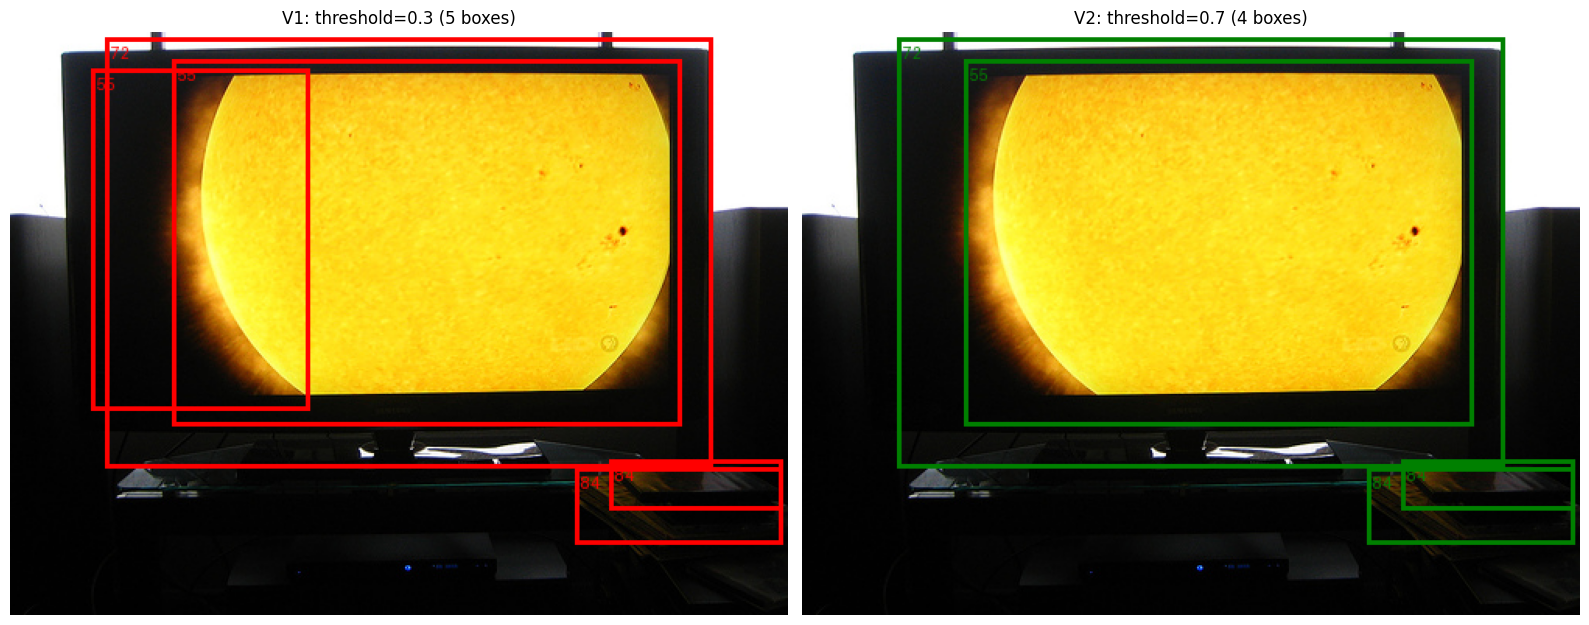

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# V1 визуализация
img_v1 = draw_bounding_boxes(
    (img_tensor * 255).to(torch.uint8),
    boxes_v1,
    labels=[str(l.item()) for l in labels_v1],
    colors='red',
    width=3
)
axes[0].imshow(img_v1.permute(1, 2, 0))
axes[0].set_title(f'V1: threshold=0.3 ({len(boxes_v1)} boxes)')
axes[0].axis('off')

# V2 визуализация
img_v2 = draw_bounding_boxes(
    (img_tensor * 255).to(torch.uint8),
    boxes_v2,
    labels=[str(l.item()) for l in labels_v2],
    colors='green',
    width=3
)
axes[1].imshow(img_v2.permute(1, 2, 0))
axes[1].set_title(f'V2: threshold=0.7 ({len(boxes_v2)} boxes)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('artifacts/figures/detection_examples.png', dpi=150)
plt.show()

# Расчет метрик детекции

In [19]:
def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0

def extract_boxes_from_voc_target(target):
    """Извлекаем bounding boxes из VOC XML формата"""
    import xml.etree.ElementTree as ET
    
    # Парсим XML аннотацию
    annotation = target['annotation']
    objects = annotation['object']
    
    if isinstance(objects, dict):
        objects = [objects]
    
    boxes = []
    labels = []
    
    # VOC class names to indices (упрощённая версия)
    voc_classes = {
        'aeroplane': 1, 'bicycle': 2, 'bird': 3, 'boat': 4,
        'bottle': 5, 'bus': 6, 'car': 7, 'cat': 8, 'chair': 9,
        'cow': 10, 'diningtable': 11, 'dog': 12, 'horse': 13,
        'motorbike': 14, 'person': 15, 'pottedplant': 16,
        'sheep': 17, 'sofa': 18, 'train': 19, 'tvmonitor': 20
    }
    
    for obj in objects:
        bndbox = obj['bndbox']
        xmin = float(bndbox['xmin'])
        ymin = float(bndbox['ymin'])
        xmax = float(bndbox['xmax'])
        ymax = float(bndbox['ymax'])
        
        boxes.append([xmin, ymin, xmax, ymax])
        
        class_name = obj['name']
        labels.append(voc_classes.get(class_name, 1))
    
    if len(boxes) > 0:
        return {
            'boxes': torch.tensor(boxes, dtype=torch.float32),
            'labels': torch.tensor(labels, dtype=torch.int64)
        }
    else:
        return {
            'boxes': torch.zeros((0, 4), dtype=torch.float32),
            'labels': torch.zeros(0, dtype=torch.int64)
        }

def evaluate_detection(model, dataset, score_threshold, device, iou_threshold=0.5, num_samples=10):
    model.eval()
    tp, fp, fn = 0, 0, 0
    ious = []
    
    for i in range(num_samples):
        img, target = dataset[i]
        img_tensor = transforms.ToTensor()(img)
        
        # Извлекаем boxes из VOC формата
        target_processed = extract_boxes_from_voc_target(target)
        
        with torch.no_grad():
            prediction = model([img_tensor.to(device)])
        
        pred_boxes = prediction[0]['boxes'][prediction[0]['scores'] > score_threshold]
        gt_boxes = target_processed['boxes']
        
        matched_gt = set()
        for pb in pred_boxes:
            best_iou = 0
            best_gt_idx = -1
            for j, gb in enumerate(gt_boxes):
                if j not in matched_gt:
                    iou = calculate_iou(pb.cpu(), gb.cpu())
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = j
            
            if best_iou >= iou_threshold:
                tp += 1
                matched_gt.add(best_gt_idx)
                ious.append(best_iou)
            else:
                fp += 1
        
        fn += len(gt_boxes) - len(matched_gt)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    mean_iou = np.mean(ious) if ious else 0
    
    return precision, recall, mean_iou

# Оценка V1 и V2
prec_v1, rec_v1, miou_v1 = evaluate_detection(model_det, det_dataset, 0.3, device)
prec_v2, rec_v2, miou_v2 = evaluate_detection(model_det, det_dataset, 0.7, device)

print(f"V1 (0.3) - Precision: {prec_v1:.3f}, Recall: {rec_v1:.3f}, Mean IoU: {miou_v1:.3f}")
print(f"V2 (0.7) - Precision: {prec_v2:.3f}, Recall: {rec_v2:.3f}, Mean IoU: {miou_v2:.3f}")

V1 (0.3) - Precision: 0.274, Recall: 1.000, Mean IoU: 0.774
V2 (0.7) - Precision: 0.500, Recall: 0.706, Mean IoU: 0.817


# Визуализация метрик детекции

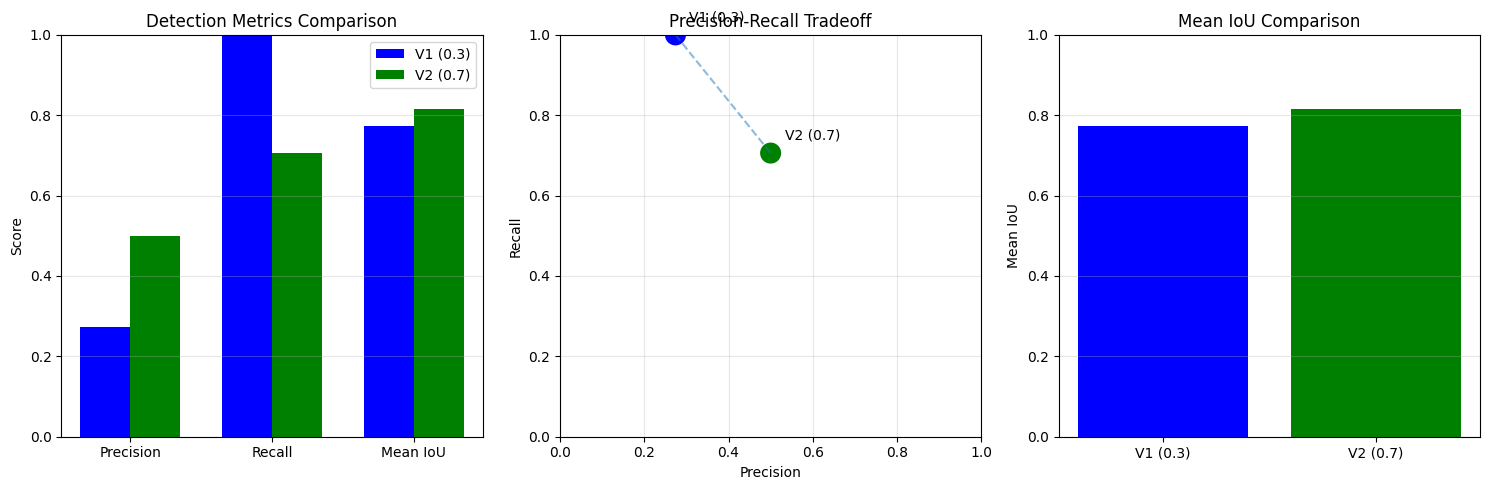

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['Precision', 'Recall', 'Mean IoU']
v1_vals = [prec_v1, rec_v1, miou_v1]
v2_vals = [prec_v2, rec_v2, miou_v2]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, v1_vals, width, label='V1 (0.3)', color='blue')
axes[0].bar(x + width/2, v2_vals, width, label='V2 (0.7)', color='green')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Score')
axes[0].set_title('Detection Metrics Comparison')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1)

# Precision-Recall tradeoff
axes[1].scatter([prec_v1, prec_v2], [rec_v1, rec_v2], s=200, c=['blue', 'green'])
axes[1].plot([prec_v1, prec_v2], [rec_v1, rec_v2], '--', alpha=0.5)
axes[1].annotate('V1 (0.3)', (prec_v1, rec_v1), textcoords="offset points", xytext=(10,10))
axes[1].annotate('V2 (0.7)', (prec_v2, rec_v2), textcoords="offset points", xytext=(10,10))
axes[1].set_xlabel('Precision')
axes[1].set_ylabel('Recall')
axes[1].set_title('Precision-Recall Tradeoff')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

# IoU comparison
axes[2].bar(['V1 (0.3)', 'V2 (0.7)'], [miou_v1, miou_v2], color=['blue', 'green'])
axes[2].set_ylabel('Mean IoU')
axes[2].set_title('Mean IoU Comparison')
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('artifacts/figures/detection_metrics.png', dpi=150)
plt.show()

# Создание runs.csv

In [21]:
runs_data = [
    {
        'experiment_id': 'C1',
        'task': 'classification',
        'dataset': DATASET_NAME,
        'seed': SEED,
        'model_summary': 'SimpleCNN',
        'optimizer': 'Adam',
        'lr': 0.001,
        'epochs_trained': EPOCHS,
        'best_val_accuracy': best_val_acc_c1,
        'test_accuracy': '',
        'precision': '',
        'recall': '',
        'mean_iou': '',
        'notes': 'No augmentations'
    },
    {
        'experiment_id': 'C2',
        'task': 'classification',
        'dataset': DATASET_NAME,
        'seed': SEED,
        'model_summary': 'SimpleCNN',
        'optimizer': 'Adam',
        'lr': 0.001,
        'epochs_trained': EPOCHS,
        'best_val_accuracy': best_val_acc_c2,
        'test_accuracy': '',
        'precision': '',
        'recall': '',
        'mean_iou': '',
        'notes': 'With augmentations'
    },
    {
        'experiment_id': 'C3',
        'task': 'classification',
        'dataset': DATASET_NAME,
        'seed': SEED,
        'model_summary': 'ResNet18',
        'optimizer': 'Adam',
        'lr': 0.001,
        'epochs_trained': EPOCHS,
        'best_val_accuracy': best_val_acc_c3,
        'test_accuracy': '',
        'precision': '',
        'recall': '',
        'mean_iou': '',
        'notes': 'Head-only (frozen backbone)'
    },
    {
        'experiment_id': 'C4',
        'task': 'classification',
        'dataset': DATASET_NAME,
        'seed': SEED,
        'model_summary': 'ResNet18',
        'optimizer': 'Adam',
        'lr': 0.001,
        'epochs_trained': EPOCHS,
        'best_val_accuracy': best_val_acc_c4,
        'test_accuracy': '',
        'precision': '',
        'recall': '',
        'mean_iou': '',
        'notes': 'Fine-tune (layer4+fc)'
    },
    {
        'experiment_id': 'V1',
        'task': 'detection',
        'dataset': 'VOCDetection',
        'seed': SEED,
        'model_summary': 'FasterRCNN_ResNet50_FPN',
        'optimizer': '',
        'lr': '',
        'epochs_trained': '',
        'best_val_accuracy': '',
        'test_accuracy': '',
        'precision': prec_v1,
        'recall': rec_v1,
        'mean_iou': miou_v1,
        'notes': 'score_threshold=0.3'
    },
    {
        'experiment_id': 'V2',
        'task': 'detection',
        'dataset': 'VOCDetection',
        'seed': SEED,
        'model_summary': 'FasterRCNN_ResNet50_FPN',
        'optimizer': '',
        'lr': '',
        'epochs_trained': '',
        'best_val_accuracy': '',
        'test_accuracy': '',
        'precision': prec_v2,
        'recall': rec_v2,
        'mean_iou': miou_v2,
        'notes': 'score_threshold=0.7'
    }
]

# Обновление test_accuracy для лучшего эксперимента
for run in runs_data:
    if run['experiment_id'] == best_exp:
        run['test_accuracy'] = test_accuracy

df_runs = pd.DataFrame(runs_data)
df_runs.to_csv('artifacts/runs.csv', index=False)
print("runs.csv создан!")
print(df_runs.to_string())

runs.csv создан!
  experiment_id            task       dataset  seed            model_summary optimizer     lr epochs_trained best_val_accuracy test_accuracy precision    recall  mean_iou                        notes
0            C1  classification         STL10    42                SimpleCNN      Adam  0.001             20              60.4                                                         No augmentations
1            C2  classification         STL10    42                SimpleCNN      Adam  0.001             20              66.3                                                       With augmentations
2            C3  classification         STL10    42                 ResNet18      Adam  0.001             20              94.7                                              Head-only (frozen backbone)
3            C4  classification         STL10    42                 ResNet18      Adam  0.001             20              96.1        95.425                                      Fine-

# Итоговая сводка

In [22]:
print("=" * 60)
print("ИТОГОВАЯ СВОДКА HW10-11")
print("=" * 60)

print(f"\nЧасть A (Классификация):")
print(f"  - Датасет: {DATASET_NAME}")
print(f"  - Лучший эксперимент: {best_exp}")
print(f"  - Best Val Accuracy: {results[best_exp]:.2f}%")
print(f"  - Test Accuracy: {test_accuracy:.2f}%")
print(f"  - Эффект аугментаций (C2 vs C1): {best_val_acc_c2 - best_val_acc_c1:+.2f}%")
print(f"  - Эффект Transfer Learning (C3 vs C1): {best_val_acc_c3 - best_val_acc_c1:+.2f}%")
print(f"  - Head-only vs Fine-tune (C4 vs C3): {best_val_acc_c4 - best_val_acc_c3:+.2f}%")

print(f"\nЧасть B (Детекция):")
print(f"  - Модель: FasterRCNN_ResNet50_FPN")
print(f"  - V1 (threshold=0.3): Precision={prec_v1:.3f}, Recall={rec_v1:.3f}, IoU={miou_v1:.3f}")
print(f"  - V2 (threshold=0.7): Precision={prec_v2:.3f}, Recall={rec_v2:.3f}, IoU={miou_v2:.3f}")
print(f"  - Tradeoff: При увеличении порога precision растёт, recall падает")

print(f"\nАртефакты сохранены в ./artifacts/")

ИТОГОВАЯ СВОДКА HW10-11

Часть A (Классификация):
  - Датасет: STL10
  - Лучший эксперимент: C4
  - Best Val Accuracy: 96.10%
  - Test Accuracy: 95.42%
  - Эффект аугментаций (C2 vs C1): +5.90%
  - Эффект Transfer Learning (C3 vs C1): +34.30%
  - Head-only vs Fine-tune (C4 vs C3): +1.40%

Часть B (Детекция):
  - Модель: FasterRCNN_ResNet50_FPN
  - V1 (threshold=0.3): Precision=0.274, Recall=1.000, IoU=0.774
  - V2 (threshold=0.7): Precision=0.500, Recall=0.706, IoU=0.817
  - Tradeoff: При увеличении порога precision растёт, recall падает

Артефакты сохранены в ./artifacts/
